# Initial Data Processing

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp

Processing data for wavelength: 404.7 nm


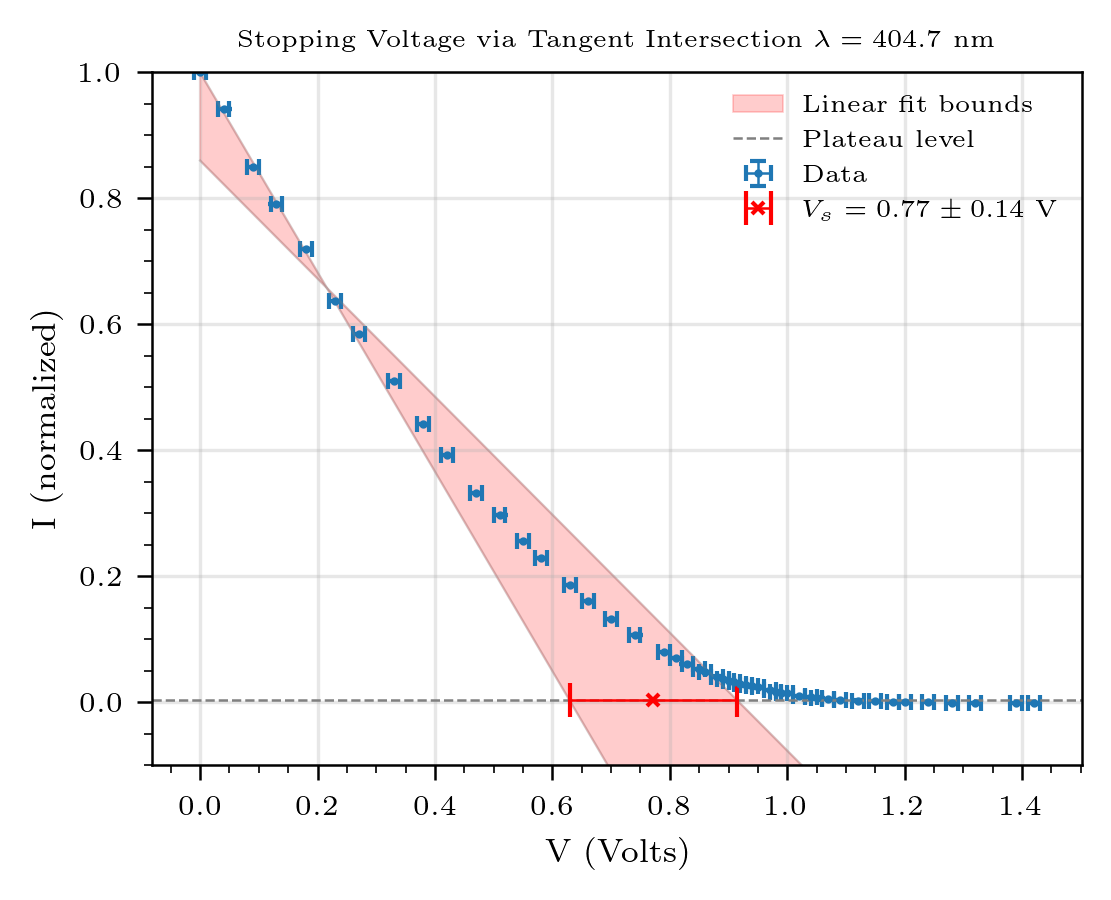

Processing data for wavelength: 435.8 nm


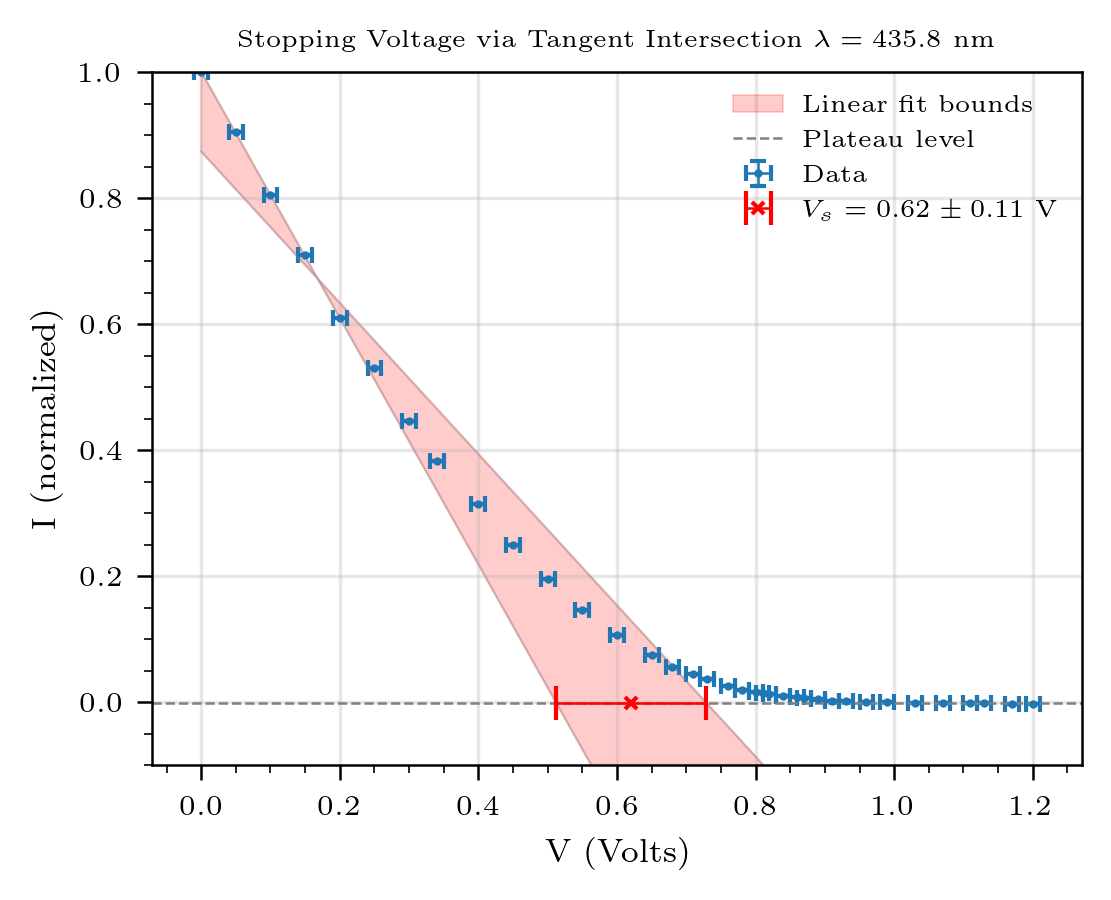

Processing data for wavelength: 577.0 nm


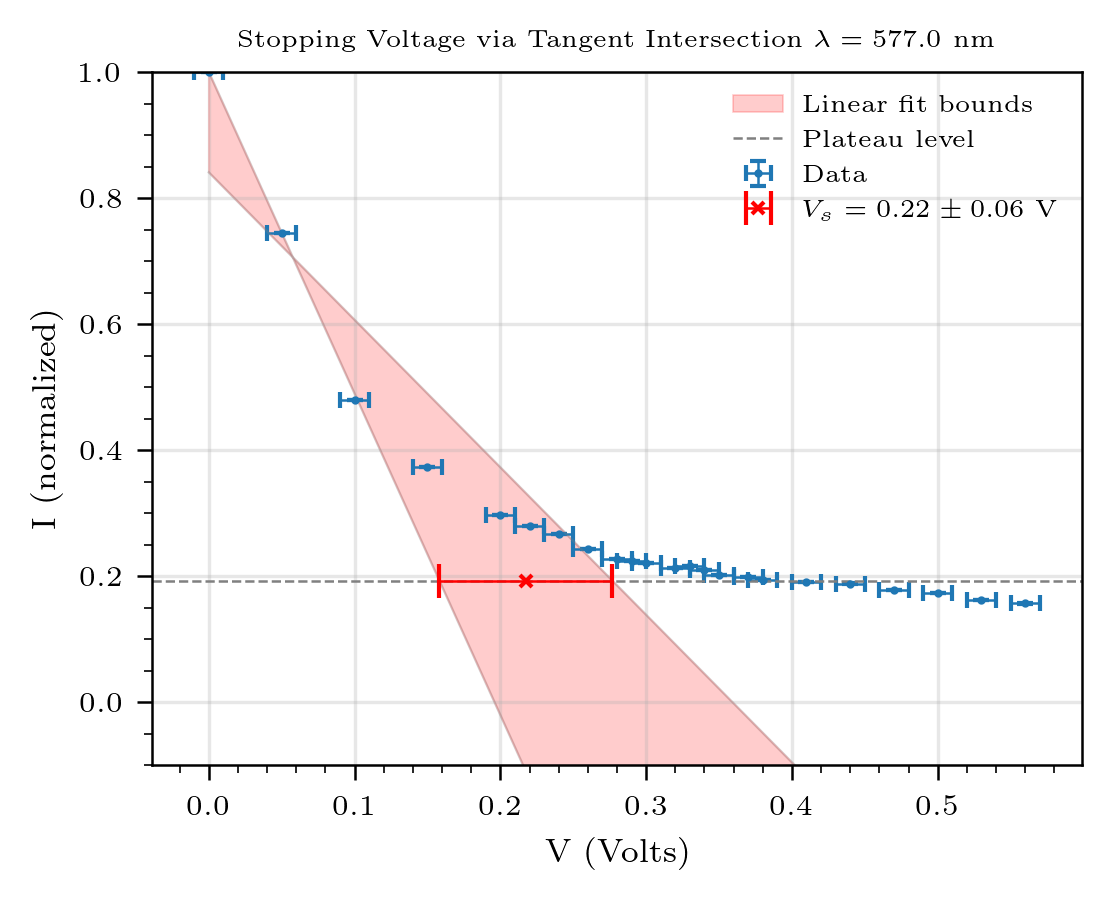

[np.float64(0.771804549183003), np.float64(0.6204260850353993), np.float64(0.21756690584996966)]
[np.float64(0.1426792610948961), np.float64(0.10829584623710148), np.float64(0.05933376904109347)]


In [36]:
plt.style.use("./jlab.mplstyle")

wavelengths = np.array([404.7, 435.8, 577.0])
linear_masks_upper = [1.0, 0.8, 0.3]
linear_masks_lower = [0.2, 0.1, 0.05]
plateau_masks = [1.0, 0.9, 0.3]

V_stops = []
V_stops_unc = []

power_supply_unc = 0.01  # Uncertainty in voltage measurement (volts)

# 1. Define the linear model
def linear(x, m, c):
    return m * x + c

for i in range(len(wavelengths)):
    plt.figure(figsize=(4, 3))

    wavelength = wavelengths[i]
    print(f"Processing data for wavelength: {wavelength} nm")
    df = pd.read_csv(f"{wavelength}.csv")
    V_all = df["V"].values
    I_all = np.mean(df[["I1","I2","I3","I4","I5"]].values, axis=1)
    I_unc = np.std(df[["I1","I2","I3","I4","I5"]].values, axis=1) / np.sqrt(5)  # Standard error of the mean
    V_unc = np.full_like(I_unc, power_supply_unc) # Assuming negligible voltage uncertainty
    

    #Normalize current
    I_all = I_all / np.max(I_all)

    V_lin_upper = V_all[V_all <= linear_masks_upper[i]]
    V_lin_lower = V_all[V_all <= linear_masks_lower[i]]

    I_lin_upper = I_all[V_all <= linear_masks_upper[i]]
    I_lin_lower = I_all[V_all <= linear_masks_lower[i]]

    V_plat = V_all[V_all >= plateau_masks[i]]
    I_plat = I_all[V_all >= plateau_masks[i]]


    # --- linear fit ---
    m1u, b1u = np.polyfit(V_lin_upper, I_lin_upper, 1)
    m1l, b1l = np.polyfit(V_lin_lower, I_lin_lower, 1)

    # --- forced plateau (slope = 0) ---
    b2 = np.mean(I_plat)
    m2 = 0

    # --- intersection ---
    V_stop_u = (b2 - b1u) / m1u
    V_stop_l = (b2 - b1l) / m1l

    V_stop = (V_stop_u + V_stop_l) / 2
    V_stop_unc = abs(V_stop_u - V_stop_l) / 2

    V_stops.append(V_stop)
    V_stops_unc.append(V_stop_unc)

    I_stop = b2

    plt.errorbar(V_all, I_all, yerr = I_unc, fmt="o", xerr = V_unc, markersize=1.0, capsize=2.0 , label="Data")

    V_fit = np.linspace(min(V_all), max(V_all), 200)

    plt.plot(V_fit, m1u*V_fit + b1u, color="gray",alpha=0.3)
    plt.plot(V_fit, m1l*V_fit + b1l, color="gray",alpha=0.3)
    plt.fill_between(V_fit, m1u*V_fit + b1u, m1l*V_fit+b1l, color="red", alpha=0.2, label="Linear fit bounds")
    # plt.plot(V_fit, np.full_like(V_fit, b2), label="Plateau (forced slope=0)")

    # plt.scatter(V_stop, I_stop, s=60, marker="x", label="Intersection")
    #plot horizontal dashed line at I_stop
    plt.axhline(I_stop, color="gray", linestyle="--", label="Plateau level")
    plt.errorbar(V_stop, I_stop, xerr=V_stop_unc, fmt="x", color="red", markersize=3, capsize=4, label=rf"$V_s = {V_stop:.2f} \pm {V_stop_unc:.2f}$ V")
    
    plt.xlabel("V (Volts)")
    plt.ylim(-0.1, 1.0)
    plt.ylabel("I (normalized)")
    plt.title(rf"Stopping Voltage via Tangent Intersection $\lambda = {wavelength}$ nm",fontsize=6)
    plt.legend()
    plt.grid(True,alpha=0.3)
    plt.show()
print(V_stops)
print(V_stops_unc)
    

# Estimating h

In [37]:

# wavelengths in nm (example — replace with yours)
wave_unc = 2  # Uncertainty in wavelength measurement (nm)

c = 299792458  # speed of light (m/s)

# convert nm -> m, then compute frequency
frequencies = c / (wavelengths * 1e-9)
freq_unc = (c / (wavelengths * 1e-9)**2) * wave_unc * 1e-9  # propagate uncertainty



In [44]:

from scipy.odr import ODR, Model, RealData

def linear_odr(beta, x):
    return beta[0] * x + beta[1]

V_stops = [1.25, 1.05, 0.45]  

data = RealData(frequencies, np.array(V_stops), sx=freq_unc, sy=np.array(V_stops_unc))
odr_result = ODR(data, Model(linear_odr), beta0=[3.799e-15, -1.0]).run()

m, b = odr_result.beta
m_err = odr_result.sd_beta[0]

h_over_e = m
print("h/e =", h_over_e)


h/e = 3.591960867531646e-15


In [45]:
e = 1.602e-19
h_est = e * h_over_e

print("Estimated h =", h_est, "J·s")
print("Error: ", m_err * e, "J·s")

Estimated h = 5.754321309785697e-34 J·s
Error:  5.0490328957615636e-36 J·s


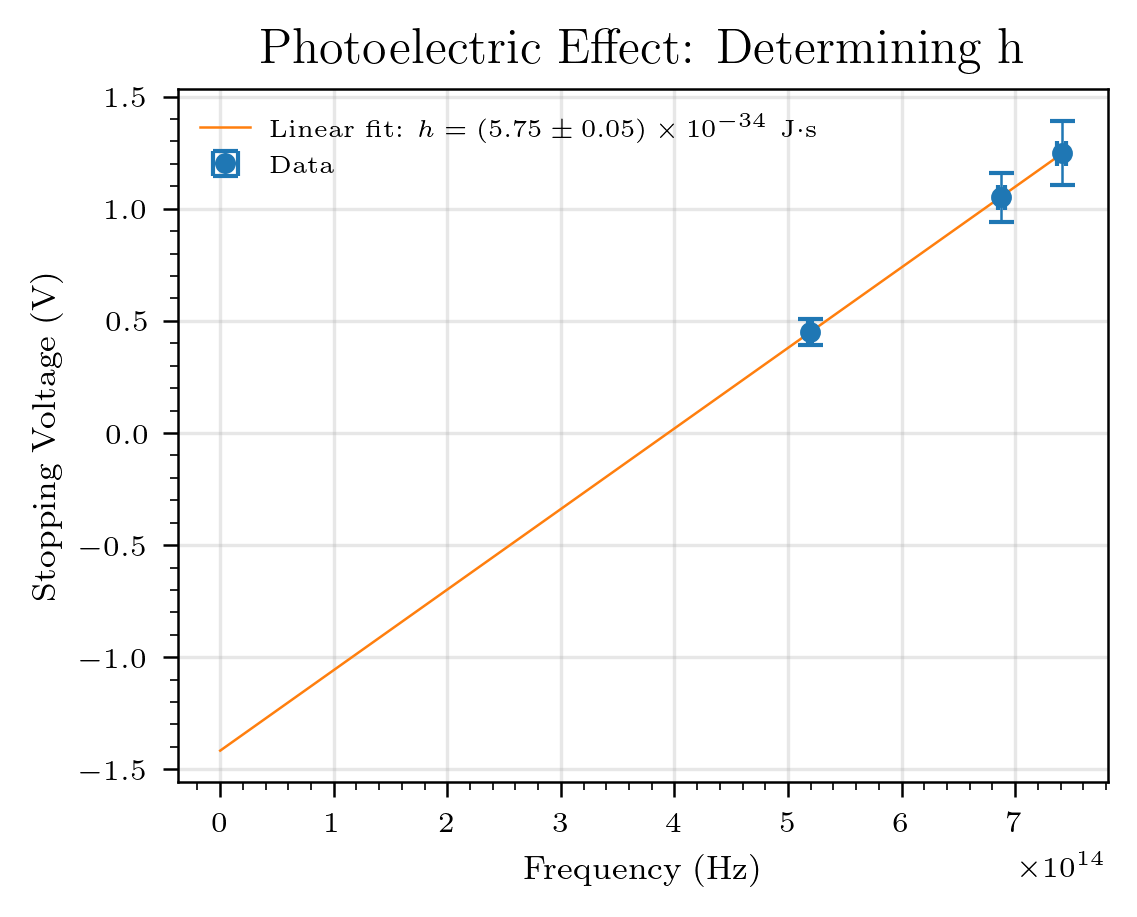

In [46]:

plt.figure(figsize=(4,3))
plt.errorbar(frequencies, V_stops, yerr=V_stops_unc, xerr=freq_unc, fmt='o', markersize=4.0, capsize=3.0, label="Data")

# best fit line
f_fit = np.linspace(0, max(frequencies), 200)
plt.plot(f_fit, m*f_fit + b, label=rf"Linear fit: $h = ({h_est/1e-34:.2f} \pm {m_err*e/1e-34:.2f}) \times 10^{{-34}}$ J·s")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Stopping Voltage (V)")
plt.title("Photoelectric Effect: Determining h")
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()
